# **Telecom X - Cancelacion de Clientes (Churn)**

Partiendo de los datos analizados, se construye un Pipeline de pre-procesamiento y modelado que permite identificar clientes con mayo probabilidad de cancelar el servicio.

## ***1. Importacion de Librerias***

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

## ***2. Extracion de los  datos tratados***

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/AIS-Tobe/Alura_Store_Challenge_03_EQ/main/datos_churn_tratados.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0,1
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1,1


In [5]:
# Hacemos una copia del DataFrame para mantener los datos tratados en posteriores analisis
df_ml = df.copy()

In [6]:
# Eliminamos columnas sin relevancia
df_ml.drop(columns=["customerID", "Churn"], inplace=True)

# Verifico de estructura
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer.gender            7043 non-null   object 
 1   customer.SeniorCitizen     7043 non-null   int64  
 2   customer.Partner           7043 non-null   object 
 3   customer.Dependents        7043 non-null   object 
 4   customer.tenure            7043 non-null   int64  
 5   phone.PhoneService         7043 non-null   object 
 6   phone.MultipleLines        7043 non-null   object 
 7   internet.InternetService   7043 non-null   object 
 8   internet.OnlineSecurity    7043 non-null   object 
 9   internet.OnlineBackup      7043 non-null   object 
 10  internet.DeviceProtection  7043 non-null   object 
 11  internet.TechSupport       7043 non-null   object 
 12  internet.StreamingTV       7043 non-null   object 
 13  internet.StreamingMovies   7043 non-null   objec

In [7]:
df_ml["Churn_bin"].value_counts(normalize=True)

,proportion
Churn_bin,
0,0.73463
1,0.26537


## ***3. Analisis de Correlacion***

Se analizara respecto a la variable objetivo (Churn) para analizar desbalances posibles entre Clientes que cancelan y Clientes que permanecen activos.

In [8]:
# Selecciono columnas numéricas
numeric_cols = df_ml.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'account.Charges.Total', 'Cuentas_Diarias', 'Churn_bin',
       'PaperlessBilling_bin'],
      dtype='object')

In [11]:
corr_matrix = df_ml[numeric_cols].corr()
corr_matrix

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin
customer.SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.220173,0.150889,0.156530
customer.tenure,0.016567,1.000000,0.247900,0.826178,0.247900,-0.352229,0.006152
account.Charges.Monthly,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356,0.352150
account.Charges.Total,0.103006,0.826178,0.651174,1.000000,0.651174,-0.198324,0.158574
Cuentas_Diarias,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356,0.352150
Churn_bin,0.150889,-0.352229,0.193356,-0.198324,0.193356,1.000000,0.191825
PaperlessBilling_bin,0.156530,0.006152,0.352150,0.158574,0.352150,0.191825,1.000000


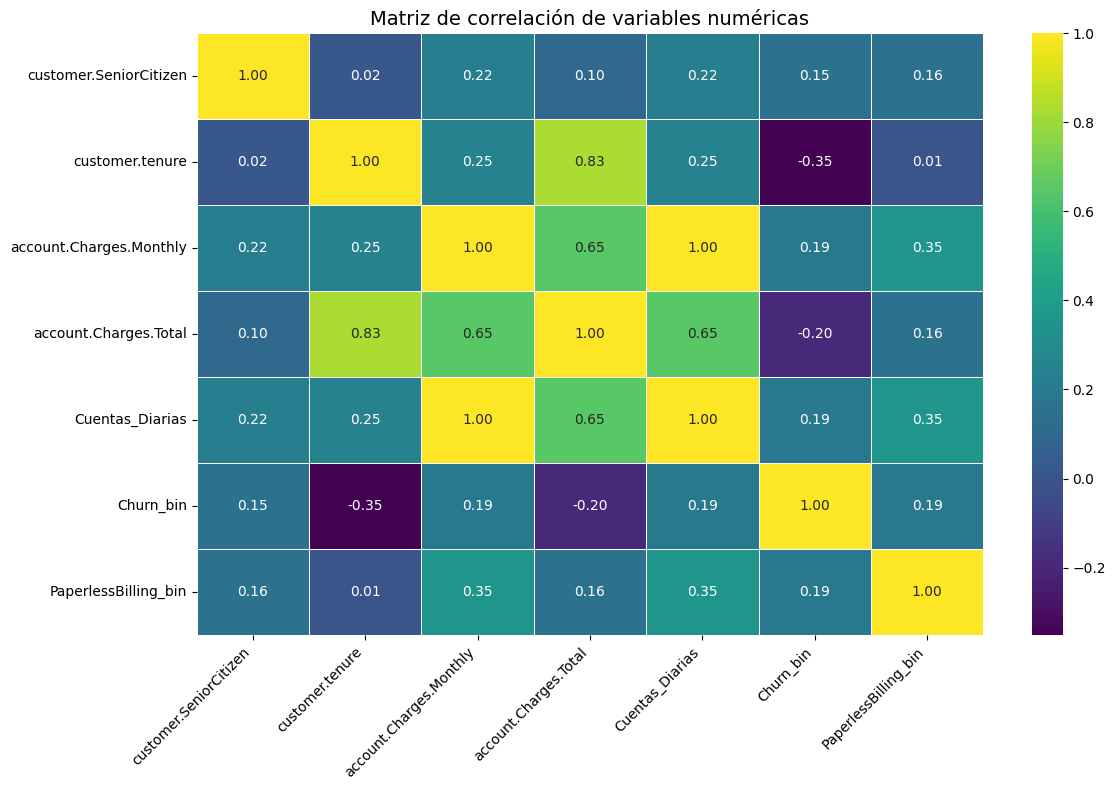

In [13]:
plt.figure(figsize=(12, 8)) # Increased figure size for better readability
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="viridis", # Changed colormap to 'viridis' for a more modern and perceptually uniform look
    fmt=".2f",
    linewidths=.5, # Added linewidths for better separation of cells
    annot_kws={"size": 10} # Increased annotation font size
)
plt.title("Matriz de correlación de variables numéricas", fontsize=14) # Increased title font size
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

- Existe una correlación negativa moderada entre la antigüedad del cliente `(customer.tenure)` y el churn, lo que indica que los clientes con más tiempo en la empresa tienen menor probabilidad de cancelar.
- Asimismo, el total gastado `(account.Charges.Total)` también muestra una relación negativa con la cancelación, ya que está asociado a una mayor permanencia.
- Por otro lado, los cargos mensuales `(account.Charges.Monthly)` presentan una ligera correlación positiva con el churn.

 En general, no se observan correlaciones muy fuertes, lo que sugiere que la cancelación de clientes depende de varios factores combinados.

## ***4. Enfoque del Analisis***

Comparamos las relaciones entre la variable clave y la cancelacion de clientes para identificar Patrones

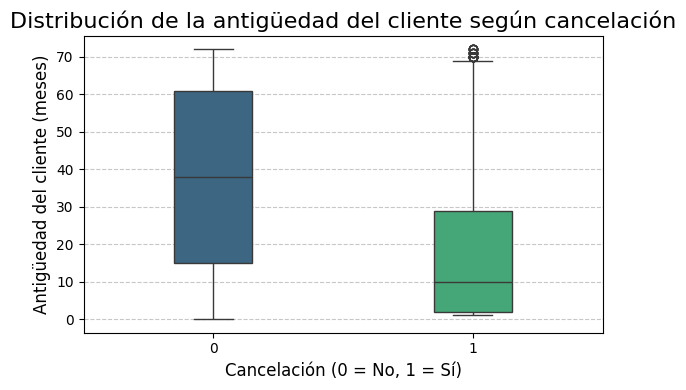

In [20]:
plt.figure(figsize=(6, 4)) # Reduced figure size
sns.boxplot(
    x="Churn_bin",
    y="customer.tenure",
    data=df_ml,
    palette="viridis", # Changed color palette
    hue="Churn_bin", # Assign x to hue to address FutureWarning
    legend=False, # Set legend=False since hue is explicitly defined as x
    width=0.3 # Added to control the thickness of the boxes
)
plt.title("Distribución de la antigüedad del cliente según cancelación", fontsize=16) # Increased title font size
plt.xlabel("Cancelación (0 = No, 1 = Sí)", fontsize=12) # Increased x-label font size
plt.ylabel("Antigüedad del cliente (meses)", fontsize=12) # Increased y-label font size
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added a grid
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

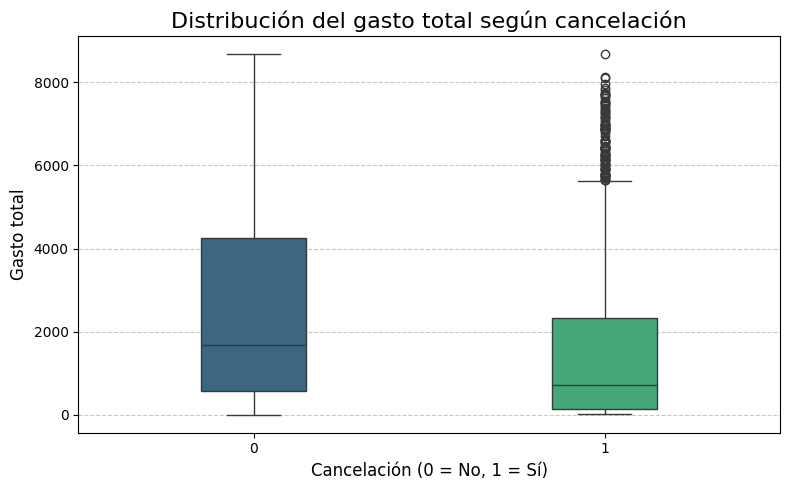

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn_bin",
    y="account.Charges.Total",
    data=df_ml,
    palette="viridis",
    hue="Churn_bin",
    legend=False,
    width=0.3
)
plt.title("Distribución del gasto total según cancelación", fontsize=16)
plt.xlabel("Cancelación (0 = No, 1 = Sí)", fontsize=12)
plt.ylabel("Gasto total", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Los clientes que cancelan el servicio suelen tener menor antigüedad en comparación con los que permanecen activos. En consecuencia, también presentan un gasto total acumulado más bajo. Esto sugiere que los clientes con mayor tiempo en la empresa generan más valor y tienen menor probabilidad de cancelar.

## ***5. Definicion de variables predictoras***

In [24]:
# Defino variables predictoras y variable objetivo
X = df_ml.drop(columns=["Churn_bin"])
y = df_ml["Churn_bin"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

## ***6. Encoding y pre-procesamiento de Datos***

In [27]:
# Columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols, numeric_cols

(Index(['customer.gender', 'customer.Partner', 'customer.Dependents',
        'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
        'internet.OnlineSecurity', 'internet.OnlineBackup',
        'internet.DeviceProtection', 'internet.TechSupport',
        'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
        'account.PaperlessBilling', 'account.PaymentMethod'],
       dtype='object'),
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias', 'PaperlessBilling_bin'],
       dtype='object'))

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4930, 42), (2113, 42))

In [30]:
("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
("num", "passthrough", numeric_cols)

('num',
 'passthrough',
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias', 'PaperlessBilling_bin'],
       dtype='object'))

In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4930, 42), (2113, 42))

## ***7. Modelos de Clasificacion***

In [32]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_test_processed)

### *Arbol de Decision - Modelo 1*

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

### *Regresion con Normalizacion - Modelo 2*

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

## ***8. Evaluacion de los modelos***

In [39]:
def evaluar_modelo(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

In [42]:
resultados = {
    "Baseline (Dummy)": evaluar_modelo(y_test, y_pred_dummy),
    "Árbol de Decisión": evaluar_modelo(y_test, y_pred_dt),
    "Regresión Logística": evaluar_modelo(y_test, y_pred_logreg)
}

resultados_df = pd.DataFrame(resultados).T
resultados_df

,Accuracy,Precision,Recall,F1-score
Baseline (Dummy),0.734501,0.000000,0.000000,0.000000
Árbol de Decisión,0.728822,0.489899,0.518717,0.503896
Regresión Logística,0.796971,0.639831,0.538324,0.584705


El modelo baseline muestra una alta accuracy debido al desbalance de clases, pero no logra detectar correctamente a los clientes que cancelan. El Árbol de Decisión mejora la identificación del churn, aunque con menor precisión. Por su parte, la Regresión Logística ofrece el mejor balance entre precision y recall, obteniendo el mayor F1-score, por lo que presenta el mejor rendimiento general.

## ***9. Matriz de Confusion***

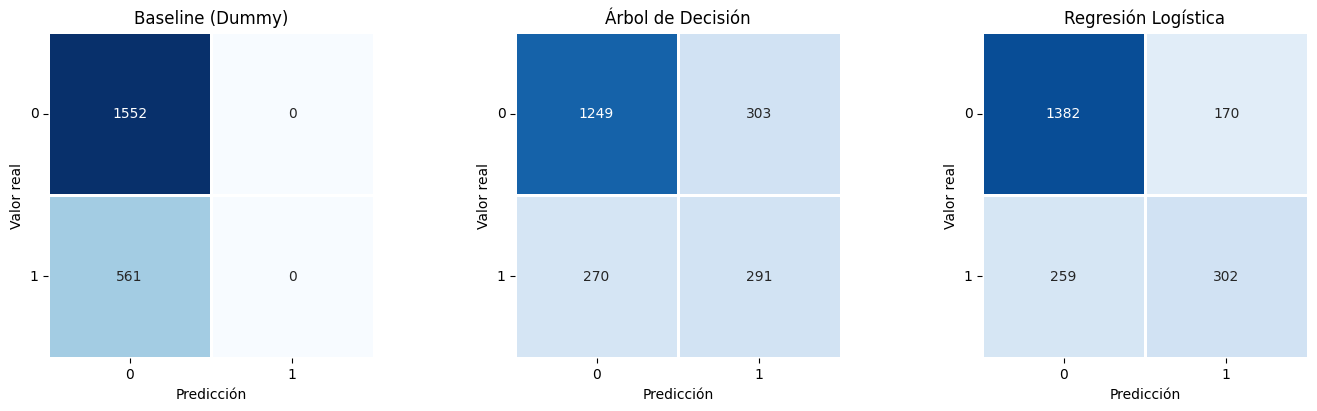

In [43]:
# --- Matrices de confusión ---
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

cms = [cm_dummy, cm_dt, cm_logreg]
titulos = ["Baseline (Dummy)", "Árbol de Decisión", "Regresión Logística"]

# Matrices (CONTEOS ABSOLUTOS) — escala común
vmax = max(cm.max() for cm in cms)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="white",
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()

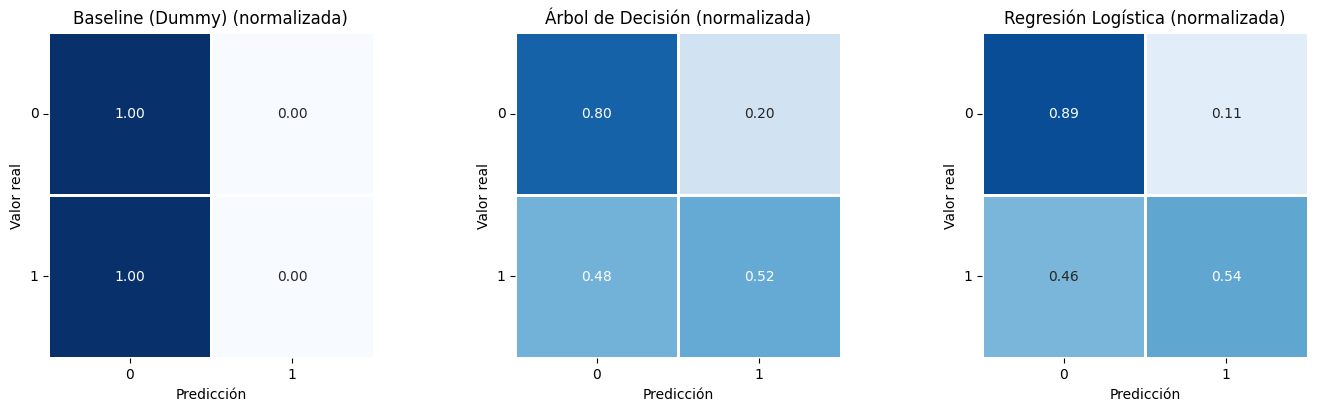

In [44]:
# Matrices por fila
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="white",
        ax=ax
    )
    ax.set_title(f"{titulo} (normalizada)")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()

Contribucion de Variables principales

In [47]:
# Obtenemos los nombres de las variables luego del One-Hot Encoding
ohe = preprocessor.named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

# Unimos categóricas codificadas + numéricas
feature_names = np.concatenate([encoded_cat_cols, numeric_cols])

len(feature_names)

42

In [48]:
# Extraemos coeficientes de la regresión logística
coeficientes = logreg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficientes
})

coef_df.head()

,Variable,Coeficiente
0,customer.gender_Male,-0.086402
1,customer.Partner_Yes,-0.032902
2,customer.Dependents_Yes,-0.202550
3,phone.PhoneService_Yes,-0.220971
4,phone.MultipleLines_No,-0.246190


In [49]:
# Variables que aumentan la probabilidad de churn
top_positive = coef_df.sort_values("Coeficiente", ascending=False).head(10)
top_positive

,Variable,Coeficiente
39,account.Charges.Total,1.256297
28,account.Contract_Month-to-month,0.633932
8,internet.InternetService_Fiber optic,0.401710
34,account.PaymentMethod_Electronic check,0.245238
41,PaperlessBilling_bin,0.203393
31,account.PaperlessBilling_Yes,0.203393
19,internet.TechSupport_No,0.189754
36,customer.SeniorCitizen,0.166790
10,internet.OnlineSecurity_No,0.136302
24,internet.StreamingTV_Yes,0.108010


In [51]:
# Variables que reducen la probabilidad de cancelación
top_negative = coef_df.sort_values("Coeficiente").head(10)
top_negative

,Variable,Coeficiente
37,customer.tenure,-3.207906
30,account.Contract_Two year,-0.684750
7,internet.InternetService_DSL,-0.423110
4,phone.MultipleLines_No,-0.246190
3,phone.PhoneService_Yes,-0.220971
21,internet.TechSupport_Yes,-0.211154
2,customer.Dependents_Yes,-0.202550
33,account.PaymentMethod_Credit card (automatic),-0.199242
17,internet.DeviceProtection_No internet service,-0.157717
20,internet.TechSupport_No internet service,-0.157717


### Variables principales en la cancelacion

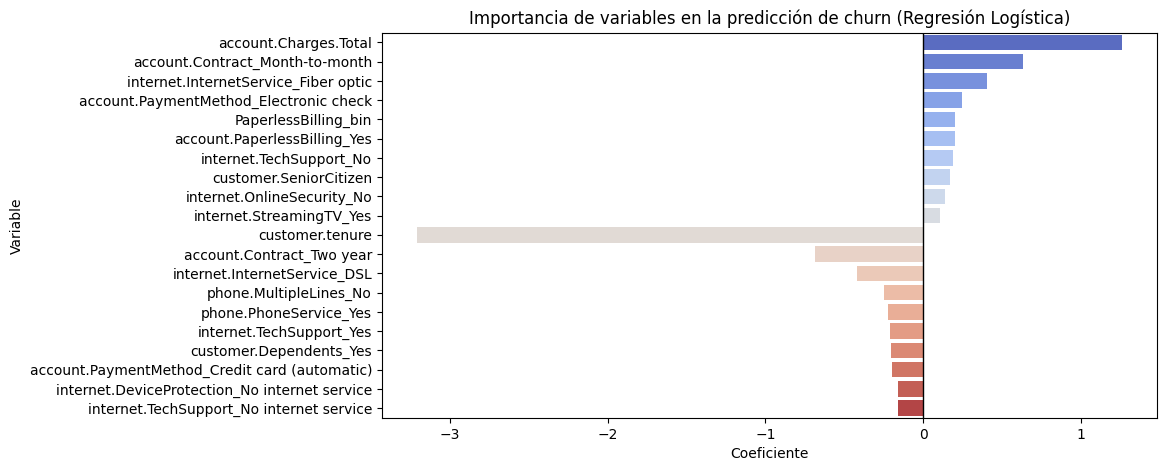

In [54]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=pd.concat([top_positive, top_negative]),
    x="Coeficiente",
    y="Variable",
    palette="coolwarm",
    hue="Variable",
    legend=False
)

plt.title("Importancia de variables en la predicción de churn (Regresión Logística)")
plt.axvline(0, color="black", linewidth=1)
plt.show()

## ***10. Reporte Final***

- La Regresión Logística presentó el mejor desempeño general, logrando el mayor F1-score y un buen equilibrio entre precisión y detección de churn. El Árbol de Decisión mostró resultados aceptables y buena interpretabilidad, mientras que el modelo baseline evidenció las limitaciones de usar únicamente la accuracy.

- El análisis de variables indicó que clientes con menor antigüedad y contratos de corto plazo tienen mayor probabilidad de cancelar, mientras que mayor permanencia y contratos más largos se asocian con menor churn, evidenciando que la cancelación depende de la combinación de múltiples factores.